In [1]:
import pyPLUTO as pp
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np

PyPLUTO version: 1.0   session: Jupyter notebook or qtconsole


# 2A) Compare the quality of the MHD wave modeling for different Riemann solvers 
- with FLAT reconstruction and EULER time-stepping
- To do this, change the Solver option in the .ini file between roe, hll, hllc, and hlld. 
- Visualize the fields $\rho, p, v_x, v_y, B_y$, and $B_z$.
- Plot the different solutions in the same figure for direct comparison, and use distinct colors or line styles to distinguish the curves.

### hll Riemann Solver:

In [2]:
# Load PLUTO simulation output data
D = pp.Load(
    'all',          # Load all available output files / time steps
    vars=True,      # Also load primitive variables (rho, v, p, B, etc.)
    datatype='dbl', # Use double-precision data files
    path="/dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/hll"  # Directory containing the simulation outputs
)

# Select a specific time frame (same index will be used for all variables)
i = 1              # Frame index (e.g., second output snapshot)
x = D.x1           # 1D spatial grid along the x-direction

# Bundle selected variables together with LaTeX-style labels for plotting
vars_data_hll = [
    (D.rho[i],  r'$\rho$'),   # Mass density
    (D.Bx2[i],  r'$B_y$'),    # Transverse magnetic field component By
    (D.Bx3[i],  r'$B_z$'),    # Transverse magnetic field component Bz
    (D.prs[i],  r'$p$'),      # Thermal pressure
    (D.vx1[i],  r'$v_x$'),    # Velocity component in x-direction
    (D.vx2[i],  r'$v_y$'),    # Velocity component in y-direction
]

Load: folder /dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/hll,     output [0, 1]


### hllc Riemann Solver:

In [3]:
# Load PLUTO simulation output data
D = pp.Load(
    'all',          # Load all available output files / time steps
    vars=True,      # Also load primitive variables (rho, v, p, B, etc.)
    datatype='dbl', # Use double-precision data files
    path="/dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/hllc"  # Directory containing the simulation outputs
)

# Select a specific time frame (same index will be used for all variables)
i = 1              # Frame index (e.g., second output snapshot)
x = D.x1           # 1D spatial grid along the x-direction

# Bundle selected variables together with LaTeX-style labels for plotting
vars_data_hllc = [
    (D.rho[i],  r'$\rho$'),   # Mass density
    (D.Bx2[i],  r'$B_y$'),    # Transverse magnetic field component By
    (D.Bx3[i],  r'$B_z$'),    # Transverse magnetic field component Bz
    (D.prs[i],  r'$p$'),      # Thermal pressure
    (D.vx1[i],  r'$v_x$'),    # Velocity component in x-direction
    (D.vx2[i],  r'$v_y$'),    # Velocity component in y-direction
]

Load: folder /dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/hllc,     output [0, 1]


### hlld Riemann Solver:

In [4]:
# Load PLUTO simulation output data
D = pp.Load(
    'all',          # Load all available output files / time steps
    vars=True,      # Also load primitive variables (rho, v, p, B, etc.)
    datatype='dbl', # Use double-precision data files
    path="/dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/hlld"  # Directory containing the simulation outputs
)

# Select a specific time frame (same index will be used for all variables)
i = 1              # Frame index (e.g., second output snapshot)
x = D.x1           # 1D spatial grid along the x-direction

# Bundle selected variables together with LaTeX-style labels for plotting
vars_data_hlld = [
    (D.rho[i],  r'$\rho$'),   # Mass density
    (D.Bx2[i],  r'$B_y$'),    # Transverse magnetic field component By
    (D.Bx3[i],  r'$B_z$'),    # Transverse magnetic field component Bz
    (D.prs[i],  r'$p$'),      # Thermal pressure
    (D.vx1[i],  r'$v_x$'),    # Velocity component in x-direction
    (D.vx2[i],  r'$v_y$'),    # Velocity component in y-direction
]

Load: folder /dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/hlld,     output [0, 1]


### roe Riemann Solver:

In [5]:
# Load PLUTO simulation output data
D = pp.Load(
    'all',          # Load all available output files / time steps
    vars=True,      # Also load primitive variables (rho, v, p, B, etc.)
    datatype='dbl', # Use double-precision data files
    path="/dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/roe"  # Directory containing the simulation outputs
)

# Select a specific time frame (same index will be used for all variables)
i = 1              # Frame index (e.g., second output snapshot)
x = D.x1           # 1D spatial grid along the x-direction

# Bundle selected variables together with LaTeX-style labels for plotting
vars_data_roe = [
    (D.rho[i],  r'$\rho$'),   # Mass density
    (D.Bx2[i],  r'$B_y$'),    # Transverse magnetic field component By
    (D.Bx3[i],  r'$B_z$'),    # Transverse magnetic field component Bz
    (D.prs[i],  r'$p$'),      # Thermal pressure
    (D.vx1[i],  r'$v_x$'),    # Velocity component in x-direction
    (D.vx2[i],  r'$v_y$'),    # Velocity component in y-direction
]

Load: folder /dartfs-hpc/rc/home/s/f005d7s/hw5/p2/a/roe,     output [0, 1]


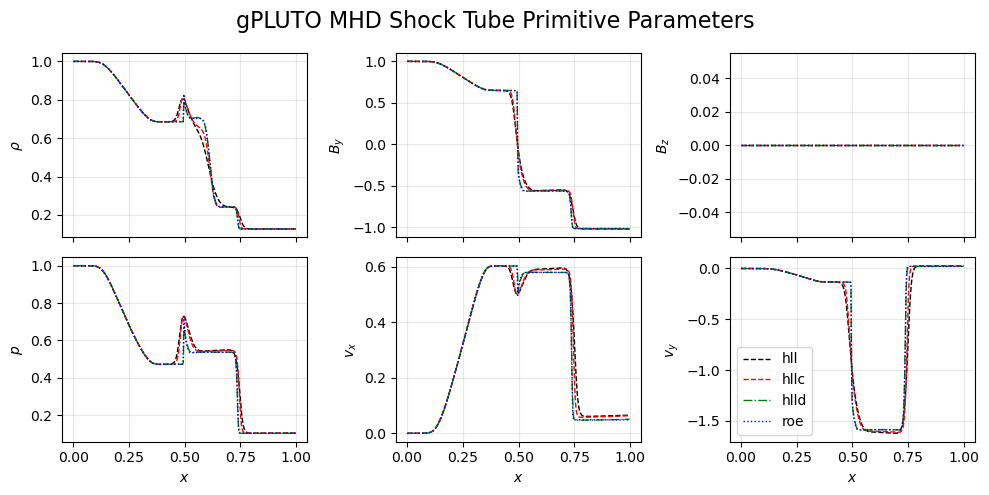

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True)
fig.suptitle('gPLUTO MHD Shock Tube Primitive Parameters', fontsize=16)

for ax, (data, variable) in zip(axes.flat, vars_data_hll):
    ax.plot(x, data, color='black', lw=1, ls='--', label='hll')
    ax.set_ylabel(variable)
    ax.grid(alpha=0.3)

for ax, (data, variable) in zip(axes.flat, vars_data_hllc):
    ax.plot(x, data, color='r', lw=1, ls='--', label='hllc')
    ax.set_ylabel(variable)
    ax.grid(alpha=0.3)

for ax, (data, variable) in zip(axes.flat, vars_data_hlld):
    ax.plot(x, data, color='g', lw=1, ls='-.', label='hlld')
    ax.set_ylabel(variable)
    ax.grid(alpha=0.3)

for ax, (data, variable) in zip(axes.flat, vars_data_roe):
    ax.plot(x, data, color='b', lw=1, ls=':', label='roe')
    ax.set_ylabel(variable)
    ax.grid(alpha=0.3)

# X labels only on bottom row
for ax in axes[1, :]:
    ax.set_xlabel(r'$x$')

plt.legend()
plt.tight_layout()
plt.savefig('Shock_tube_flat_Euler.png', dpi=600)
plt.show()